<a href="https://colab.research.google.com/github/QuintonPang/Predicting-Bike-Sharing-Demand-An-End-to-End-Machine-Learning-Analysis/blob/main/bike_sharing_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lakshmi25npathi/bike-sharing-dataset")

print("Path to dataset files:", path)

100%|██████████| 286k/286k [00:00<00:00, 60.8MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/lakshmi25npathi/bike-sharing-dataset/versions/1


In [ ]:
import pandas as pd

# Load dataset (assuming you have hour.csv from UCI Bike Sharing Dataset)
df = pd.read_csv(path+'/hour.csv')

# Basic inspection
print(df.shape)          # rows, columns
print(df.head())         # first 5 rows
print(df.info())         # data types & nulls
print(df.columns.tolist())


(17379, 17)
   instant      dteday  season  yr  mnth  hr  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1   0        0        6           0   
1        2  2011-01-01       1   0     1   1        0        6           0   
2        3  2011-01-01       1   0     1   2        0        6           0   
3        4  2011-01-01       1   0     1   3        0        6           0   
4        5  2011-01-01       1   0     1   4        0        6           0   

   weathersit  temp   atemp   hum  windspeed  casual  registered  cnt  
0           1  0.24  0.2879  0.81        0.0       3          13   16  
1           1  0.22  0.2727  0.80        0.0       8          32   40  
2           1  0.22  0.2727  0.80        0.0       5          27   32  
3           1  0.24  0.2879  0.75        0.0       3          10   13  
4           1  0.24  0.2879  0.75        0.0       0           1    1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data column

In [ ]:
# 1. Check for missing values
print(df.isnull().sum())

# 2. Check data types
print(df.dtypes)

# Convert dteday to actual datetime
df['dteday'] = pd.to_datetime(df['dteday'])

# 3. Check for duplicates
print("Duplicate rows:", df.duplicated().sum())

# 4. Sanity check: does cnt = casual + registered?
mismatch = df[df['cnt'] != (df['casual'] + df['registered'])]
print("Mismatched rows:", len(mismatch))


instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64
instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object
Duplicate rows: 0
Mismatched rows: 0


In [ ]:
# Weak check (almost always 0, because 'instant' is unique)
print("Full-row duplicates:", df.duplicated().sum())

# Better check: ignore the ID column
print("Duplicates ignoring instant:", df.drop(columns=['instant']).duplicated().sum())

# Best check for this dataset: is each (date, hour) combo unique?
print("Duplicate date+hour combos:", df.duplicated(subset=['dteday', 'hr']).sum())


Full-row duplicates: 0
Duplicates ignoring instant: 0
Duplicate date+hour combos: 0


In [ ]:
season_map = {1: 'winter', 2: 'spring', 3: 'summer', 4: 'fall'}
weather_map = {1: 'clear', 2: 'mist/cloudy', 3: 'light rain/snow', 4: 'heavy rain/snow'}

df['season_label'] = df['season'].map(season_map)
df['weather_label'] = df['weathersit'].map(weather_map)

df[['season', 'season_label', 'weathersit', 'weather_label']].head()


,season,season_label,weathersit,weather_label
0,1,winter,1,clear
1,1,winter,1,clear
2,1,winter,1,clear
3,1,winter,1,clear
4,1,winter,1,clear


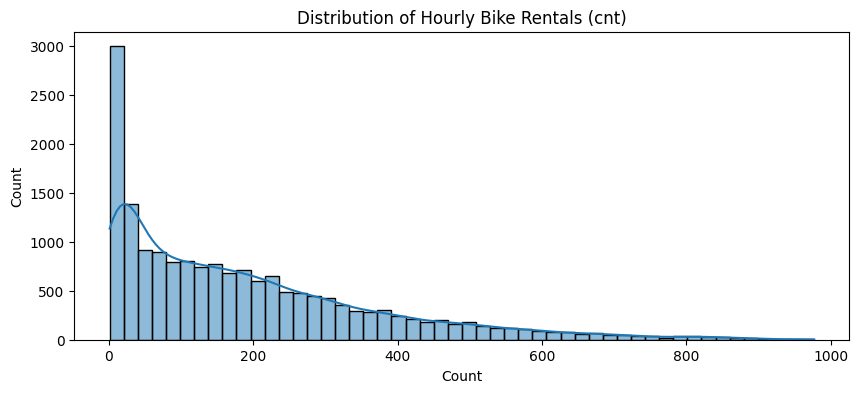

count    17379.000000
mean       189.463088
std        181.387599
min          1.000000
25%         40.000000
50%        142.000000
75%        281.000000
max        977.000000
Name: cnt, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,4))
sns.histplot(df['cnt'], bins=50, kde=True)
plt.title('Distribution of Hourly Bike Rentals (cnt)')
plt.xlabel('Count')
plt.show ()

print(df['cnt'].describe())


/tmp/ipykernel_2270/2229443114.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df, x='hr', y='cnt', estimator='mean', ci=None)


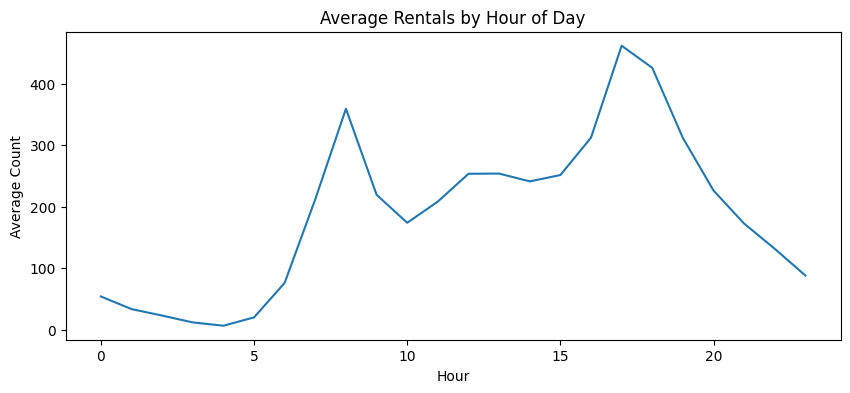

In [ ]:
plt.figure(figsize=(10,4))
sns.lineplot(data=df, x='hr', y='cnt', estimator='mean', ci=None)
plt.title('Average Rentals by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Average Count')
plt.show()


/tmp/ipykernel_2270/3619082437.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df, x='hr', y='cnt', hue='workingday', estimator='mean', ci=None)


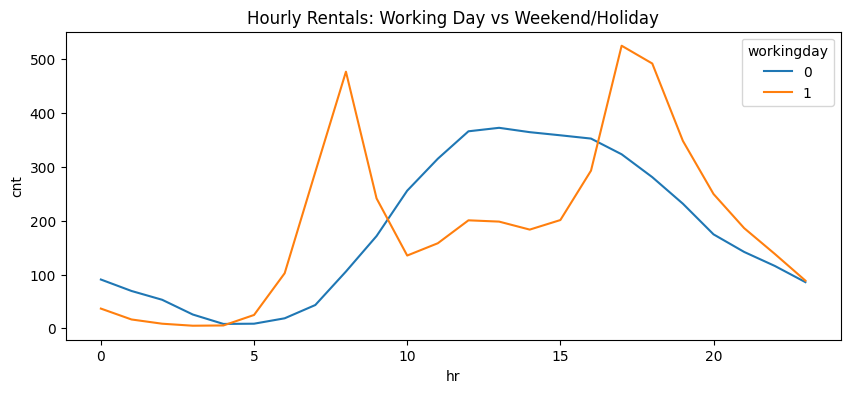

In [ ]:
plt.figure(figsize=(10,4))
sns.lineplot(data=df, x='hr', y='cnt', hue='workingday', estimator='mean', ci=None)
plt.title('Hourly Rentals: Working Day vs Weekend/Holiday')
plt.show()


/tmp/ipykernel_2270/3252386198.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='weather_label', y='cnt', estimator='mean', ci=None,


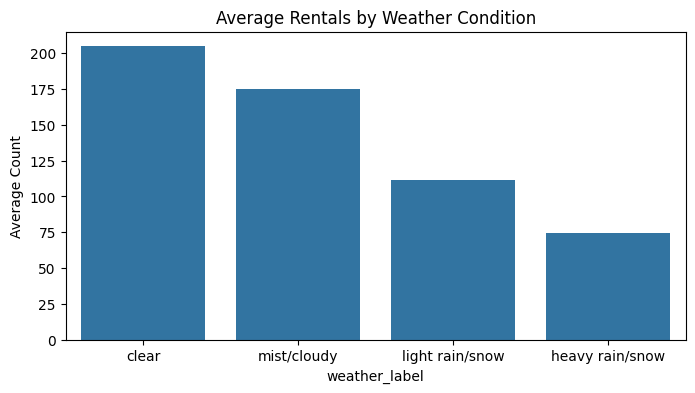

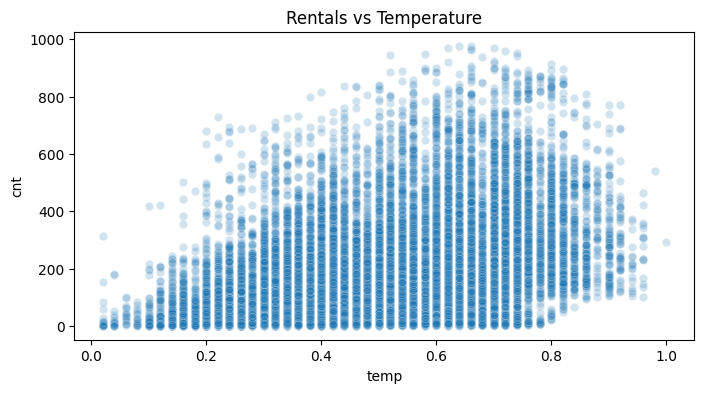

In [ ]:
# Average rentals by weather condition
plt.figure(figsize=(8,4))
sns.barplot(data=df, x='weather_label', y='cnt', estimator='mean', ci=None,
            order=['clear', 'mist/cloudy', 'light rain/snow', 'heavy rain/snow'])
plt.title('Average Rentals by Weather Condition')
plt.ylabel('Average Count')
plt.show()

# Rentals vs temperature
plt.figure(figsize=(8,4))
sns.scatterplot(data=df, x='temp', y='cnt', alpha=0.2)
plt.title('Rentals vs Temperature')
plt.show()


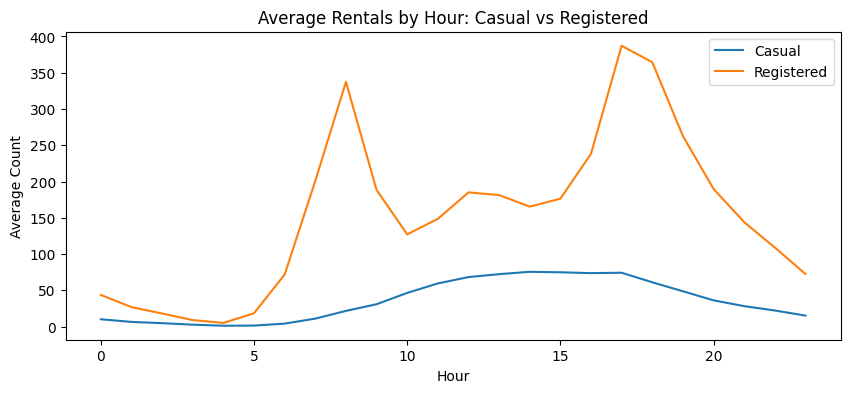

In [ ]:
# Average casual vs registered rentals by hour
hourly_avg = df.groupby('hr')[['casual', 'registered']].mean().reset_index()

plt.figure(figsize=(10,4))
plt.plot(hourly_avg['hr'], hourly_avg['casual'], label='Casual')
plt.plot(hourly_avg['hr'], hourly_avg['registered'], label='Registered')
plt.legend()
plt.title('Average Rentals by Hour: Casual vs Registered')
plt.xlabel('Hour')
plt.ylabel('Average Count')
plt.show()


In [ ]:
# 1. Rush hour flag
df['is_rush_hour'] = df['hr'].apply(lambda h: 1 if h in [7,8,9,17,18,19] else 0)

# 2. Day period bucket
def get_day_period(h):
    if 5 <= h < 12:
        return 'morning'
    elif 12 <= h < 17:
        return 'afternoon'
    elif 17 <= h < 21:
        return 'evening'
    else:
        return 'night'

df['day_period'] = df['hr'].apply(get_day_period)

# 3. Weekend flag (weekday: 0=Sunday, 6=Saturday in this dataset)
df['is_weekend'] = df['weekday'].apply(lambda d: 1 if d in [0,6] else 0)

# 4. Temperature category (temp is normalized 0-1 in this dataset)
def temp_category(t):
    if t < 0.3:
        return 'cold'
    elif t < 0.6:
        return 'mild'
    else:
        return 'hot'

df['temp_category'] = df['temp'].apply(temp_category)

# Check results
df[['hr','is_rush_hour','day_period','weekday','is_weekend','temp','temp_category']].head(10)


,hr,is_rush_hour,day_period,weekday,is_weekend,temp,temp_category
0,0,0,night,6,1,0.24,cold
1,1,0,night,6,1,0.22,cold
2,2,0,night,6,1,0.22,cold
3,3,0,night,6,1,0.24,cold
4,4,0,night,6,1,0.24,cold
5,5,0,morning,6,1,0.24,cold
6,6,0,morning,6,1,0.22,cold
7,7,1,morning,6,1,0.20,cold
8,8,1,morning,6,1,0.24,cold
9,9,1,morning,6,1,0.32,mild


In [ ]:
print(df.groupby('is_rush_hour')['cnt'].mean())
print(df.groupby('day_period')['cnt'].mean())
print(df.groupby('temp_category')['cnt'].mean())


is_rush_hour
0    141.765140
1    331.584841
Name: cnt, dtype: float64
day_period
afternoon    262.244719
evening      356.201441
morning      181.520583
night         65.687968
Name: cnt, dtype: float64
temp_category
cold     77.341803
hot     263.833948
mild    169.199225
Name: cnt, dtype: float64


In [ ]:
# Combine temp, windspeed, humidity into a single "harsh weather" flag
df['harsh_weather'] = ((df['temp'] < 0.2) | (df['windspeed'] > 0.5) | (df['hum'] > 0.8)).astype(int)

print(df.groupby('harsh_weather')['cnt'].mean())


harsh_weather
0    221.898888
1    104.191272
Name: cnt, dtype: float64


In [ ]:
# Compare weekend vs holiday vs regular working day patterns
print(df.groupby(['is_weekend', 'holiday'])['cnt'].mean())


is_weekend  holiday
0           0          193.207754
            1          156.870000
1           0          183.852014
Name: cnt, dtype: float64


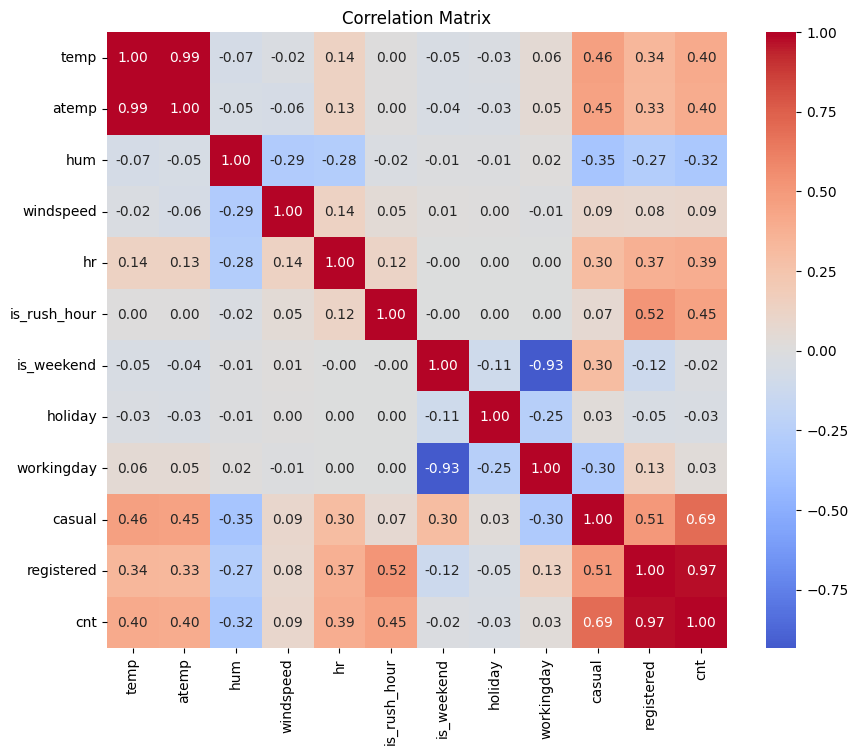

cnt             1.000000
registered      0.972151
casual          0.694564
is_rush_hour    0.453926
temp            0.404772
atemp           0.400929
hr              0.394071
windspeed       0.093234
workingday      0.030284
is_weekend     -0.019699
holiday        -0.030927
hum            -0.322911
Name: cnt, dtype: float64


In [ ]:
# Select numeric columns relevant to rentals
numeric_cols = ['temp','atemp','hum','windspeed','hr','is_rush_hour',
                 'is_weekend','holiday','workingday','casual','registered','cnt']

corr_matrix = df[numeric_cols].corr()

# Heatmap visualization
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

# Just the correlations with cnt, sorted
print(corr_matrix['cnt'].sort_values(ascending=False))


In [ ]:
# ---- Step 6: Modeling Prep (with categorical fix) ----
drop_cols = ['instant', 'dteday', 'casual', 'registered', 'cnt',
             'season_label', 'weather_label']


 #One-hot encode the categorical text columns
X = pd.get_dummies(df.drop(columns=drop_cols), columns=['day_period', 'temp_category'], drop_first=True)

print(X.columns.tolist())  # check: 'morning'/'cold' etc become separate 0/1 columns




['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'is_rush_hour', 'is_weekend', 'harsh_weather', 'day_period_evening', 'day_period_morning', 'day_period_night', 'temp_category_hot', 'temp_category_mild']


In [ ]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Step 1: lock away the test set (20%)
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 2: split remaining into train (60%) and validation (20%)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.25, random_state=42)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

# Step 3: try a few different hyperparameter settings, check each on validation set
settings = [
    {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1},
    {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1},
    {'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.05},
]

best_score = -999
best_model = None
best_setting = None

for s in settings:
    model = XGBRegressor(**s, random_state=42)
    model.fit(X_train, y_train)
    val_preds = model.predict(X_val)
    val_r2 = r2_score(y_val, val_preds)
    print(s, "-> Validation R²:", round(val_r2, 4))

    if val_r2 > best_score:
        best_score = val_r2
        best_model = model
        best_setting = s

print("\nBest setting found:", best_setting)

# Step 4: ONLY NOW, evaluate the best model on the untouched test set
test_preds = best_model.predict(X_test)
print("Final Test MAE:", mean_absolute_error(y_test, test_preds))
print("Final Test R²:", r2_score(y_test, test_preds))


Train: (10427, 20) Val: (3476, 20) Test: (3476, 20)
{'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1} -> Validation R²: 0.8834
{'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1} -> Validation R²: 0.9473
{'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.05} -> Validation R²: 0.9525

Best setting found: {'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.05}
Final Test MAE: 23.44803810119629
Final Test R²: 0.9528983235359192


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# ---- Linear Regression (no tuning needed, just one model) ----
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_val_preds = lr.predict(X_val)
lr_test_preds = lr.predict(X_test)

print("Linear Regression  -> Val R²:", round(r2_score(y_val, lr_val_preds), 4),
      " Test R²:", round(r2_score(y_test, lr_test_preds), 4),
      " Test MAE:", round(mean_absolute_error(y_test, lr_test_preds), 2))

# ---- Random Forest: try a few settings, pick best on validation ----
rf_settings = [
    {'n_estimators': 100, 'max_depth': None},
    {'n_estimators': 200, 'max_depth': 10},
    {'n_estimators': 300, 'max_depth': 15},
]

best_rf_score = -999
best_rf_model = None
best_rf_setting = None

for s in rf_settings:
    model = RandomForestRegressor(**s, random_state=42)
    model.fit(X_train, y_train)
    val_preds = model.predict(X_val)
    val_r2 = r2_score(y_val, val_preds)
    print(s, "-> Validation R²:", round(val_r2, 4))

    if val_r2 > best_rf_score:
        best_rf_score = val_r2
        best_rf_model = model
        best_rf_setting = s

rf_test_preds = best_rf_model.predict(X_test)
print("\nBest RF setting:", best_rf_setting)
print("Random Forest -> Test R²:", round(r2_score(y_test, rf_test_preds), 4),
      " Test MAE:", round(mean_absolute_error(y_test, rf_test_preds), 2))


Linear Regression  -> Val R²: 0.6311  Test R²: 0.6204  Test MAE: 82.14
{'n_estimators': 100, 'max_depth': None} -> Validation R²: 0.9453
{'n_estimators': 200, 'max_depth': 10} -> Validation R²: 0.9296
{'n_estimators': 300, 'max_depth': 15} -> Validation R²: 0.9443

Best RF setting: {'n_estimators': 100, 'max_depth': None}
Random Forest -> Test R²: 0.9432  Test MAE: 25.17


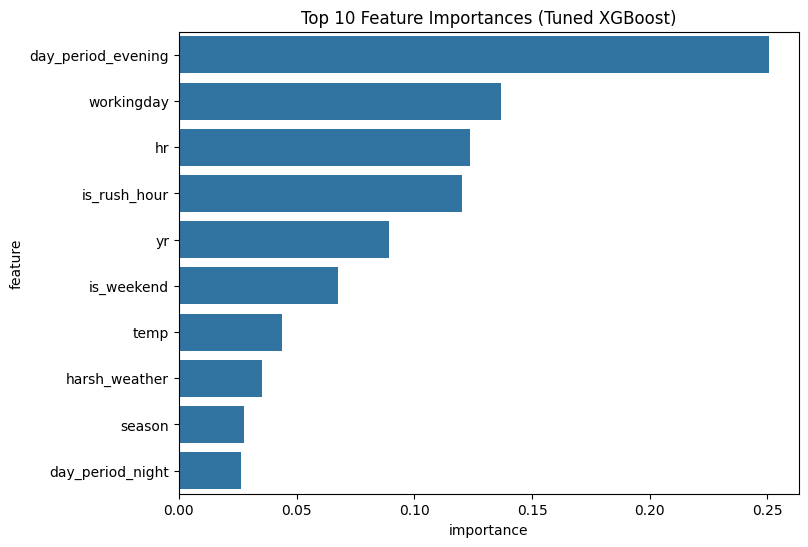

               feature  importance
15  day_period_evening    0.250803
6           workingday    0.136859
3                   hr    0.123806
12        is_rush_hour    0.120056
1                   yr    0.089203
13          is_weekend    0.067371
8                 temp    0.043906
14       harsh_weather    0.035094
0               season    0.027573
17    day_period_night    0.026266

Random Forest top features:
               feature  importance
3                   hr    0.465102
8                 temp    0.120931
1                   yr    0.082991
15  day_period_evening    0.062767
6           workingday    0.060190
12        is_rush_hour    0.045446
10                 hum    0.025292
9                atemp    0.022570
0               season    0.018212
2                 mnth    0.017915


In [ ]:
import pandas as pd

# Feature importance from the tuned XGBoost model (our best model)
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': best_model.feature_importances_  # this is the tuned XGBoost from earlier
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(data=importance_df.head(10), x='importance', y='feature')
plt.title('Top 10 Feature Importances (Tuned XGBoost)')
plt.show()

print(importance_df.head(10))

# Compare with Random Forest's importance too
rf_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': best_rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nRandom Forest top features:")
print(rf_importance_df.head(10))


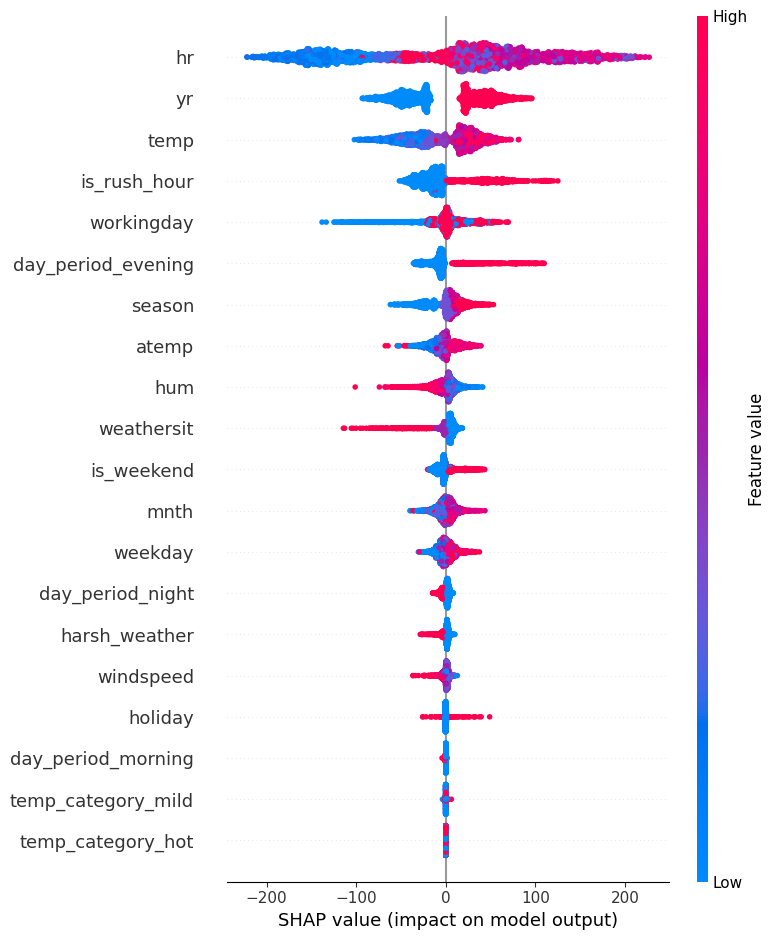

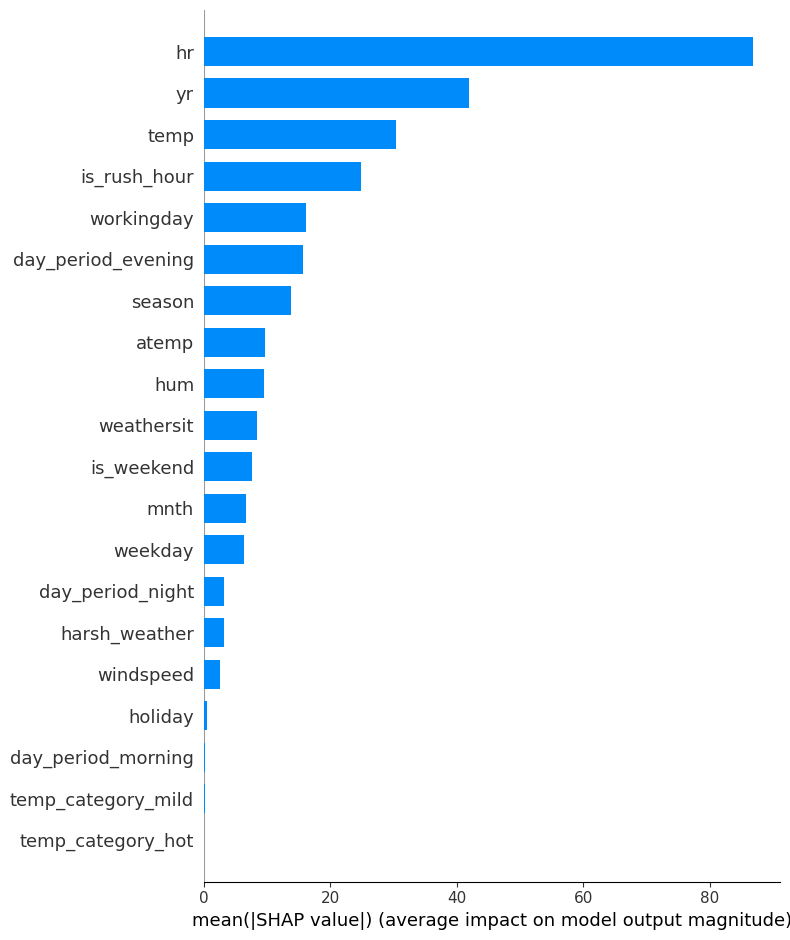

In [ ]:
# pip install shap (if not already installed)
import shap

# Create explainer for our tuned XGBoost model
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# 1. Global feature importance (SHAP version) — summary plot
shap.summary_plot(shap_values, X_test)

# 2. Bar version (cleaner ranking, similar style to what we had before)
shap.summary_plot(shap_values, X_test, plot_type='bar')

# 3. Explain ONE individual prediction (e.g., the first test row)
shap.force_plot(explainer.expected_value, shap_values[0], X_test.iloc[0])


Red = pushes prediction up. Blue = pushes prediction down. Bar length/dot spread = how much it matters.